# Image Embedding-Based Grape Leaf Disease Classification

Author: **Marcin Sikorski**<br>
Date: May, 2026

This notebook explores grape leaf disease classification using deep image embeddings extracted from pretrained convolutional neural networks. Instead of training a CNN end-to-end, pretrained backbones such as EfficientNet, MobileNet, and DenseNet are used as feature extractors, while classical machine learning models perform the final classification task. The workflow demonstrates an efficient hybrid approach that combines transfer learning with traditional ML techniques.

A common and effective workflow for image classification is:
1. Use a pretrained TensorFlow CNN as a feature extractor.
2. Convert each image into a dense embedding vector.
3. Feed the embeddings into a classical machine learning model from scikit-learn.
4. Train and evaluate the classifier.

In [ ]:
# mount G-Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


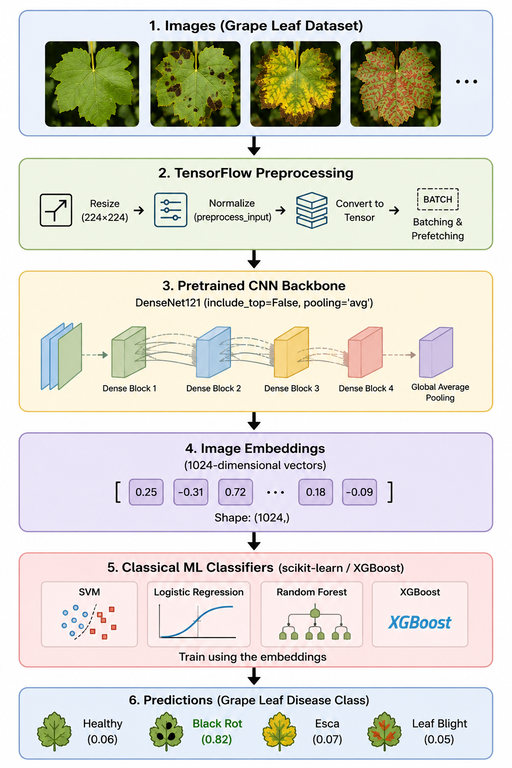

In [ ]:
# @title
from IPython.display import Image, display

display(Image('/content/drive/MyDrive/workflow_image.png', width=500))

This hybrid production workflow is widely used in real-world applications because:
* scikit-learn models train quickly,
* hyperparameter tuning is straightforward,
* many models are relatively interpretable,
* computational cost is lower,
* deployment is often simpler.

**Notebook Content:**
1. Importing and Reviewing Dataset
    1. Visualizing Dataset
2. Image Embedding Vectors
3. Predictions and Evaluation
    1. Support Vector Machines
    2. Logistic Regression
    3. Random Forest
    4. XGBoost
    5. Confusion Matrices
    6. Multiclass ROC Curves
4. Conclusions

### 1. Importing and Reviewing Dataset

The dataset is open and available on [Kaggle](https://www.kaggle.com/datasets/yusufmurtaza01/grape-leaf-diseases). It contains 4,195 images across four distinct classes, including healthy grape leaves and three common diseases: Black Rot, Esca (Black Measles), and Leaf Blight (Isariopsis Leaf Spot). The dataset is already preprocessed and organized into class-specific directories, making it suitable for direct use in image classification workflows without additional data wrangling or format conversion. The dataset is distributed as a ZIP archive. To improve data loading performance during training and feature extraction, we will temporarily extract it to local SSD storage.

In [ ]:
# copy zip file from G-Drive → fast local SSD
!cp /content/drive/MyDrive/grape-leaf-diseases.zip /content/

# unzip quietly
!unzip -q /content/grape-leaf-diseases.zip -d /content/

print('Dataset ready in /content')

Dataset ready in /content


In [ ]:
import os
import random

# sample TXT file paths
file_path1 = '/content/grape/labels/train/pv_GRBR_image (658).txt'
file_path2 = '/content/grape/labels/train/pv_GRHE_image (139).txt'
file_path3 = '/content/grape/labels/train/pv_GRLB_image (70).txt'


for file_path in [file_path1, file_path2, file_path3]:
  with open(file_path, 'r') as txt_file:
    # read TXT file
    content = txt_file.read()

    # display bounding box annotations
    print(content)

    # display label (first character)
    if len(content) > 0:
      print('Label:', content[0])

0 0.498047 0.501953 0.925781 0.996094
Label: 0
2 0.501953 0.498047 0.933594 0.996094
Label: 2
3 0.505859 0.511719 0.933594 0.945312
Label: 3


The first value (integer) represents the class label. The remaining values correspond to YOLO-format bounding box annotations: x-center, y-center, width, and height. Since this project focuses on image classification rather than object detection, we only need to extract the class labels from the TXT annotation files.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# train paths
train_image_path = '/content/grape/images/train/'
train_label_path = '/content/grape/labels/train/'

train_data = []
for file_name in os.listdir(train_image_path):

  # get corresponding label in TXT file
  label_name = file_name.replace('.jpg', '.txt')

  # open TXT file and read label as integer
  with open(train_label_path + label_name) as f:
    label = int(f.read().strip()[0])

  train_data.append({
      'image_name': file_name,
      'image_label': label,
      })

# train data
df_train = pd.DataFrame(train_data, columns=['image_name', 'image_label'])
df_train.head()

,image_name,image_label
0,pv_GRES_image (462).jpg,1
1,pv_GRBR_image (1060).jpg,0
2,pv_GRBR_image (1017).jpg,0
3,pv_GRES_image (1129).jpg,1
4,pv_GRES_image (600).jpg,1


In [ ]:
# validation paths
val_image_path = '/content/grape/images/val/'
val_label_path = '/content/grape/labels/val/'

val_data = []
for file_name in os.listdir(val_image_path):

  # get corresponding label in TXT file
  label_name = file_name.replace('.jpg', '.txt')

  # open TXT file and read label as integer
  with open(val_label_path + label_name) as f:
    label = int(f.read().strip()[0])

  val_data.append({
      'image_name': file_name,
      'image_label': label,
      })

# validation data
df_val = pd.DataFrame(val_data, columns=['image_name', 'image_label'])
df_val.head()

,image_name,image_label
0,pv_GRLB_image (703).jpg,3
1,pv_GRLB_image (464).jpg,3
2,pv_GRES_image (1055).jpg,1
3,pv_GRBR_image (864).jpg,0
4,pv_GRLB_image (67).jpg,3


In [ ]:
# check data types
df_train.dtypes, df_val.dtypes

(image_name     object
 image_label     int64
 dtype: object,
 image_name     object
 image_label     int64
 dtype: object)

In [ ]:
# image count
print('Train images:', len(df_train))
print('Val images:  ', len(df_val))

Train images: 3358
Val images:   837


#### 1.1. Visualizing Dataset

We will visualize the label distribution to examine class balance and display representative samples from each class.

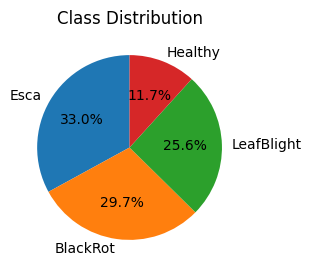

In [ ]:
# class mapping
class_map = {
    0: 'BlackRot',
    1: 'Esca',
    2: 'Healthy',
    3: 'LeafBlight',
    }

# target distribution
target_counts = df_train['image_label'].replace(class_map).value_counts()

# create a pie chart
plt.figure(figsize=(4, 3))
target_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution')
plt.ylabel(None)
plt.show()

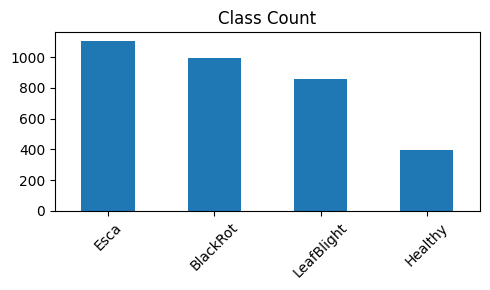

In [ ]:
plt.figure(figsize=(5, 3))

# count images per label
target_counts.plot(kind='bar')
plt.title('Class Count')
plt.xlabel(None)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The class imbalance is mild to moderate. This is generally handled well by most standard algorithms and no resampling strategies will be introduced.

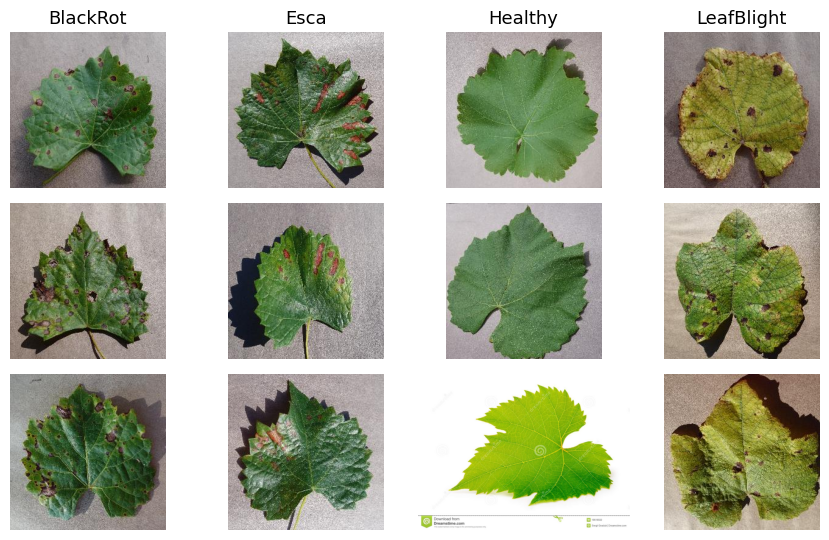

In [ ]:
from PIL import Image

# create 3 samples per class
samples = (
    df_train
    .groupby('image_label', group_keys=False)
    .sample(n=3, random_state=16)
)

# sorted class labels
classes = sorted(samples['image_label'].unique())

# create 3 x 4 grid
fig, axes = plt.subplots(3, 4, figsize=(9, 5.5))

for col_idx, cls in enumerate(classes):
  # get 3 images for each class
  class_samples = samples[samples['image_label'] == cls].reset_index(drop=True)

  for row_idx in range(3):
    ax = axes[row_idx, col_idx]

    # turn axis off
    ax.axis('off')

    # set title only on top row
    if row_idx == 0:
       ax.set_title(class_map[cls], fontsize=13)

    # load image
    image_file = class_samples.loc[row_idx, 'image_name']
    image = Image.open(train_image_path + image_file)

    # display image
    ax.imshow(image)

plt.tight_layout()
plt.show()

Leaf diseases depend heavily on texture and local patterns. Leaf disease recognition is mostly a fine-grained texture classification problem:
* spots,
* discoloration,
* edge damage,
* vein patterns,
* fungal textures,
* subtle color gradients.

We should implement models especially good at extracting hierarchical visual patterns.

### 2. Image Embedding Vectors

Image embedding vectors are mathematical representations that translate the visual content and semantic meaning of an image into a compact array of numbers (a vector). By converting unstructured pixels into organized coordinates in a high-dimensional space, machine learning models can easily measure similarities, cluster datasets, and perform semantic searches. These vectors separate diseases geometrically.

To generate image embeddings, we will typically need an embedding model and a vector dataset to store the resulting vectors. We will load a pre-trained network with TensorFlow. For detecting leaf disease common choices are:
* EfficientNetB0,
* DenseNet121,
* MobileNetV2,
* ResNet50,
* ConvNeXtTiny.

These networks are visual feature extractors optimized for texture and shape recognition with strong transfer learning performance.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model

# backbone model
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    classifier_activation='softmax',
    )

# embedding model
embedding_model = Model(
    inputs=base_model.input,
    outputs=base_model.output,
    name='DenseNet121',
    )

print('Embedding size:', embedding_model.output_shape)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Embedding size: (None, 1024)


In [ ]:
# executes ~10-17 min
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing import image

IMG_SIZE = 224
BATCH_SIZE = 32

# collect image paths + labels
image_paths = []
labels = []

datasets = [
    (train_image_path, train_label_path),
    (val_image_path, val_label_path),
]

# create labels
for image_dir, label_dir in datasets:
  for file in os.listdir(image_dir):
    img_path = os.path.join(image_dir, file)

    # convert image filename -> label filename
    label_file = os.path.splitext(file)[0] + '.txt'
    label_path = os.path.join(label_dir, label_file)

    if not os.path.exists(label_path):
      continue

    image_paths.append(img_path)

    # read class label as integer
    with open(label_path, 'r') as f:
      label = int(f.readline().split()[0])

    labels.append(label)

# image loader function
def load_image(path):
  img = image.load_img(
      path,
      target_size=(IMG_SIZE, IMG_SIZE),
      )

  img_array = image.img_to_array(img)

  return preprocess_input(img_array)


# create batches (embeddings)
X = []

num_samples = len(image_paths)

for i in range(0, num_samples, BATCH_SIZE):
  batch_paths = image_paths[i:i + BATCH_SIZE]
  batch_images = np.array([
      load_image(p) for p in batch_paths
      ])

  # generate embeddings
  embeddings = embedding_model.predict(
      batch_images,
      verbose=0,
      )

  X.extend(embeddings)

In [ ]:
# convert to NumPy arrays
X = np.array(X, dtype=np.float32)
y = np.array(labels)#.astype(int)

# embeddings and labels
print('Embeddings shape:', X.shape)
print('Labels shape:'    , y.shape)

Embeddings shape: (4195, 1024)
Labels shape: (4195,)


To diagnose embedding correctness, we can visualize diseases as clusters using t-SNE to inspect:
* whether the CNN is learning meaningful representations,
* class separability,
* confusing disease pairs,
* outliers,
* potential mislabeling.

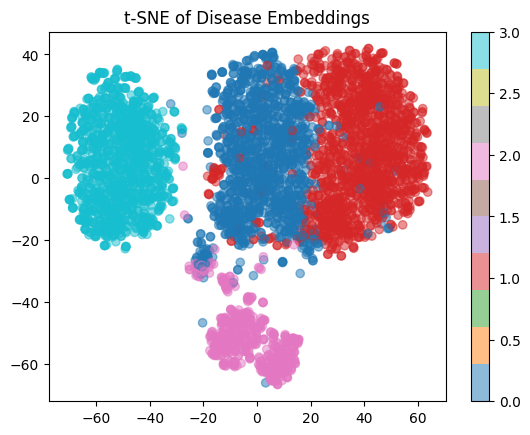

In [ ]:
from sklearn.manifold import TSNE

# exaggerate local cluster structure
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    )

X_tsne = tsne.fit_transform(X)

#plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='tab10',
    alpha=0.5,
    )

plt.colorbar(scatter)
plt.title('t-SNE of Disease Embeddings')
plt.show()

This is actually a very informative embedding visualization. The model appears to be learning meaningful disease structure. The embeddings are clearly non-random and highly structured. We can notice that:
* transfer learning is working,
* the CNN extracted useful visual features,
* the classes are geometrically separable.

This is exactly what we should expect before injecting embeddings into an sklearn classifier. Some key insights:
* **Cyan cluster (LeafBlight)**: very well separated and is visually an easy disease to predict. This class has highly distinctive visual patterns.
* **Red (BlackRot) and blue (Esca) clusters**: well separated but partially confused. These overlap significantly. The embedding model sees these two diseases are visually similar (discoloration, texture, lesion, etc.).
* **Pink cluster (Healthy)**: is well isolated and distinct. This cluster is unusual due to its vertical separation and relatively small variance. This oftens means fewer samples and visually unique disease.

Overall, the cluster compactness is good and feature extraction is strong. The plot suggests the pretrained CNN embeddings are meaningful and discriminative:
* most clusters are dense, coherent, and not diffuse;
* at least one class is highly separable;
* two classes share biologically similar visual structure;
* the embedding space is organized rather than chaotic;
* a downstream machine learning classifier should perform well.

In [ ]:
# optional: save embeddings
np.save('X_embeddings.npy', X)
np.save('y_labels.npy', y)

# load
X = np.load('X_embeddings.npy')
y = np.load('y_labels.npy')

### 3. Predictions and Evaluation

With the generated embedding vectors, we can make predictions and perform evaluations using classification metrics, confusion matrices, and related methods. For image classification, good model choices include:
* support vectors machines (SVC),
* logistic regression,
* random forest,
* XGBoost.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    )

# partion data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# class labelling
class_names = ['BlackRot', 'Esca', 'Healthy', 'LeafBlight']

#### 3.1. Support Vector Machines

In [ ]:
from sklearn.svm import SVC

# scaling data is highly recommended for SVC
svc = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', probability=True),
    )

svc.fit(X_train, y_train)

# SVC predictions
svc_pred = svc.predict(X_test)

print(classification_report(y_test, svc_pred, target_names=class_names))

print('Misclassified images: {} out of {}'.format((y_test != svc_pred).sum(), len(y_test)))

              precision    recall  f1-score   support

    BlackRot       0.98      0.97      0.98       249
        Esca       0.99      1.00      0.99       277
     Healthy       0.96      0.96      0.96        98
  LeafBlight       1.00      1.00      1.00       215

    accuracy                           0.99       839
   macro avg       0.98      0.98      0.98       839
weighted avg       0.99      0.99      0.99       839

Misclassified images: 12 out of 839


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# K-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# multiple scoring metrics
scoring = {
    'roc_auc': 'roc_auc_ovr',
    'f1': 'f1_weighted',      # for multiclass, weighted is the safest/default choice
    }

svc_scores = cross_validate(
    svc,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score='raise',
    )

print(f'Mean ROC-AUC:  {svc_scores['test_roc_auc'].mean():.4f}')
print(f'Mean F1 Score: {svc_scores['test_f1'].mean():.4f}')

# svc_scores['test_roc_auc'].std(), svc_scores['test_f1'].std()

Mean ROC-AUC:  0.9997
Mean F1 Score: 0.9881


#### 3.2. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# scaling data is required
lgr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000),
    )

lgr.fit(X_train, y_train)

# logistic regression predictions
lgr_pred = lgr.predict(X_test)

print(classification_report(y_test, lgr_pred, target_names=class_names))

print('Misclassified images: {} out of {}'.format((y_test != lgr_pred).sum(), len(y_test)))

              precision    recall  f1-score   support

    BlackRot       0.98      0.97      0.98       249
        Esca       0.99      1.00      0.99       277
     Healthy       0.96      0.97      0.96        98
  LeafBlight       1.00      1.00      1.00       215

    accuracy                           0.99       839
   macro avg       0.98      0.98      0.98       839
weighted avg       0.99      0.99      0.99       839

Misclassified images: 12 out of 839


In [ ]:
# cross-validation scoring
lgr_scores = cross_validate(
    lgr,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score='raise',
    )

print(f'Mean ROC-AUC:  {lgr_scores['test_roc_auc'].mean():.4f}')
print(f'Mean F1 Score: {lgr_scores['test_f1'].mean():.4f}')

Mean ROC-AUC:  0.9995
Mean F1 Score: 0.9911


#### 3.3. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# scaling data is not necessary
rfc = RandomForestClassifier(n_estimators=300, random_state=42)

rfc.fit(X_train, y_train)

# random forest predictions
rfc_pred = rfc.predict(X_test)

print(classification_report(y_test, rfc_pred, target_names=class_names))

print('Misclassified images: {} out of {}'.format((y_test != rfc_pred).sum(), len(y_test)))

              precision    recall  f1-score   support

    BlackRot       0.96      0.96      0.96       249
        Esca       0.97      0.97      0.97       277
     Healthy       0.99      0.97      0.98        98
  LeafBlight       0.99      1.00      1.00       215

    accuracy                           0.98       839
   macro avg       0.98      0.98      0.98       839
weighted avg       0.98      0.98      0.98       839

Misclassified images: 20 out of 839


In [ ]:
# cross-validation scoring
rfc_scores = cross_validate(
    rfc,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score='raise',
    )

print(f'Mean ROC-AUC:  {rfc_scores['test_roc_auc'].mean():.4f}')
print(f'Mean F1 Score: {rfc_scores['test_f1'].mean():.4f}')

Mean ROC-AUC:  0.9986
Mean F1 Score: 0.9791


#### 3.4. XGBoost

In [ ]:
from xgboost import XGBClassifier

# scaling data is not necessary
xgb = XGBClassifier()

xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
    )

xgb_pred = xgb.predict(X_test)

print(classification_report(y_test, xgb_pred, target_names=class_names))

print('Misclassified images: {} out of {}'.format((y_test != xgb_pred).sum(), len(y_test)))

              precision    recall  f1-score   support

    BlackRot       0.97      0.96      0.96       249
        Esca       0.97      0.98      0.97       277
     Healthy       0.99      0.98      0.98        98
  LeafBlight       0.99      1.00      1.00       215

    accuracy                           0.98       839
   macro avg       0.98      0.98      0.98       839
weighted avg       0.98      0.98      0.98       839

Misclassified images: 19 out of 839


In [ ]:
# cross-validation scoring
xgb_scores = cross_validate(
    xgb,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score='raise',
    )

print(f'Mean ROC-AUC:  {xgb_scores['test_roc_auc'].mean():.4f}')
print(f'Mean F1 Score: {xgb_scores['test_f1'].mean():.4f}')

Mean ROC-AUC:  0.9990
Mean F1 Score: 0.9803


| Model               | Misclassified Images | Mean ROC-AUC | Mean F1 Score |
| ------------------- | -------------------: | -----------: | ------------: |
| SVC                 |             12       |       0.9997 |        0.9881 |
| Logistic Regression |             12       |       0.9995 |        0.9911 |
| Random Forest       |             20       |       0.9986 |        0.9791 |
| XGBoost             |             19       |       0.9990 |        0.9803 |

* All classifiers achieved excellent performance, with extremely high ROC-AUC scores close to 1.0, indicating strong class separability.
* SVC and logistic regression produced the lowest number of misclassified images (12), demonstrating the best overall classification performance.
* Logistic regression achieved the highest mean F1 score (0.9911), suggesting the most balanced precision and recall across all classes.
* Random forest and XGBoost also performed strongly, although they produced slightly more misclassifications and lower F1 scores compared to the linear models.
* The consistently high ROC-AUC values confirm that the embedding vectors provide highly discriminative feature representations for grape leaf disease classification.
* Overall, the results suggest that the extracted embeddings are highly effective, and simpler linear classifiers such as logistic regression and SVC are sufficient to achieve near-perfect multiclass classification performance.

#### 3.5. Confusion Matrices

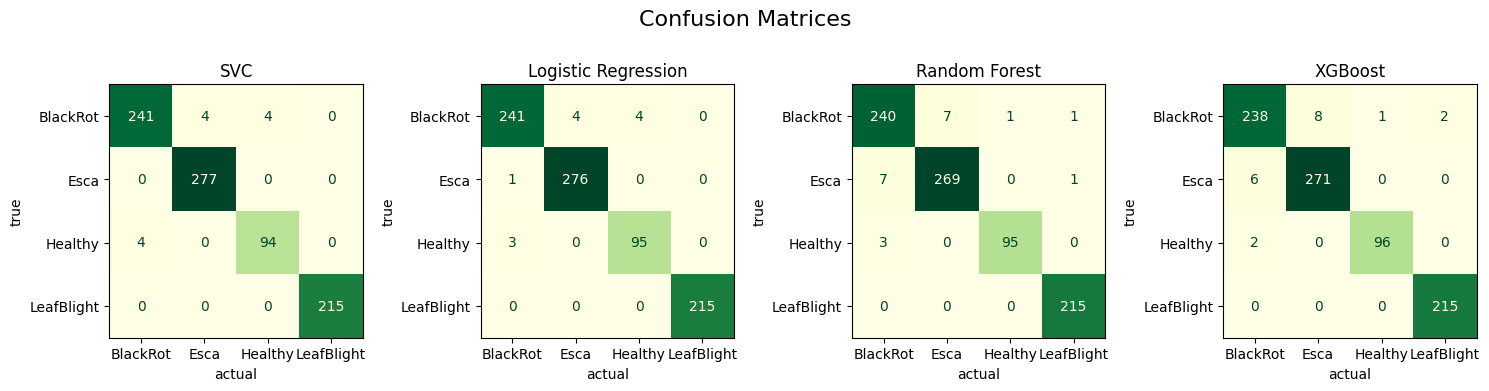

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# predictions dictionary
predictions = {
    'SVC': svc_pred,
    'Logistic Regression': lgr_pred,
    'Random Forest': rfc_pred,
    'XGBoost': xgb_pred,
    }

# create 1x4 subplot grid
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

fig.suptitle('Confusion Matrices', fontsize=16)

# plot each confusion matrix
for ax, (model_name, y_pred) in zip(axes, predictions.items()):
  ConfusionMatrixDisplay.from_predictions(
      y_test,
      y_pred,
      display_labels=class_names,
      cmap='YlGn',
      colorbar=False,
      #normalize='pred',
      ax=ax,
      )

  ax.set_title(model_name)
  ax.set_xlabel('actual')
  ax.set_ylabel('true')

plt.tight_layout()
plt.show()

Overall, all four classifiers performed very well on the grape leaf disease classification task, with strong diagonal values indicating high correct-classification rates across all classes.

General observations:
* The **LeafBlight** class was classified almost perfectly by every model, with no visible confusion with other diseases.
* Most classification errors occurred between **BlackRot** and **Esca**, suggesting these classes may share visually similar features in the embedding space (observed previously in t-SNE visualization).
* The **Healthy** class achieved consistently high accuracy across all models, although a few samples were misclassified as BlackRot.

The embedding representation appears highly effective for grape leaf disease classification, since even relatively simple, linear classifiers such as logistic regression achieved near-perfect performance. Among the evaluated methods, SVC and logistic regression showed the most balanced and consistent results across all four classes.

#### 3.6. Multiclass ROC Curves

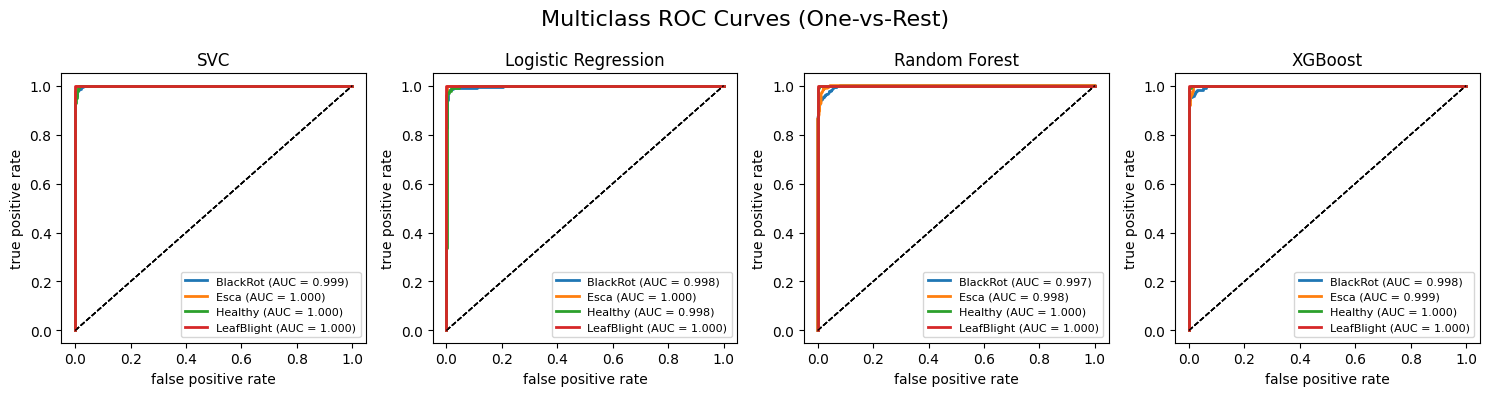

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# binarize true labels
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))

# probability predictions
probas = {
    'SVC': svc.predict_proba(X_test),
    'Logistic Regression': lgr.predict_proba(X_test),
    'Random Forest': rfc.predict_proba(X_test),
    'XGBoost': xgb.predict_proba(X_test),
    }

# create 1 x 4 subplot grid
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

fig.suptitle('Multiclass ROC Curves (One-vs-Rest)', fontsize=16)

# plot ROC for each classifier
for ax, (model_name, y_score) in zip(axes, probas.items()):

  # plot ROC curve for each class
  for i, cls in enumerate(class_names):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{cls} (AUC = {roc_auc:.3f})',
        )

    # random baseline
    ax.plot([0, 1], [0, 1], 'k--', lw=1)

    ax.set_title(model_name)
    ax.set_xlabel('false positive rate')
    ax.set_ylabel('true positive rate')
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

The multiclass ROC curves indicate that all classifiers achieved excellent discrimination performance across the four grape leaf disease classes. The ROC curves are concentrated near the upper-left corner, and all AUC values are extremely close to 1.0, demonstrating very high separability between classes.

General observations:
* All models achieved near-perfect AUC scores (≈ 0.997-1.000) for every class.
* The curves remain substantially above the random baseline, confirming strong predictive capability.
* The embedding vectors provide highly discriminative feature representations for disease classification.

Class-specific observations:
* **LeafBlight** consistently achieved an AUC of 1.0 across all classifiers, indicating perfect separability from the other classes.
* **Healthy** samples were also classified with extremely high confidence, especially by random forest and XGBoost.
* Slightly lower AUC values for **BlackRot** and **Esca** suggest these classes are comparatively more difficult to distinguish, which is consistent with the confusion matrix results. These class share similar features.

The ROC analysis confirms that the extracted embeddings are highly informative and suitable for multiclass grape leaf disease classification. All evaluated classifiers demonstrated outstanding discriminative ability.

### 4. Conclusions

In this notebook, we proposed a transfer learning approach for grape leaf disease classification using deep feature embeddings extracted from pretrained convolutional neural network (CNN). We demonstrated that CNN models pretrained on image datasets can effectively serve as feature extractors for an agricultural imaging task involving multiple grape leaf disease classes. In particular, the generated embedding vectors contained highly discriminative information that enabled traditional machine learning classifiers, to achieve excellent multiclass classification performance on the grape leaf disease dataset.

The experimental results showed that the proposed approach achieved near-perfect ROC-AUC scores and very high F1 scores, with SVC and logistic regression providing the best overall performance. These findings indicate that deep embedding representations can significantly reduce the need for training complex deep neural networks from scratch, thereby lowering computational cost, reducing training time, and minimizing the requirement for large annotated datasets.

Overall, the results confirm that transfer learning combined with embedding-based classification provides an effective and computationally efficient solution for automated grape leaf disease recognition in precision agriculture applications.

**References:**
* N. Gozzi, E. Giacomello, M. Sollini, M. Kirienko, A. Ammirabile, P. Lanzi, D. Loiacono, A. Chiti, 2022, *Image Embeddings Extracted from CNNs Outperform Other Transfer Learning Approaches in Classification of Chest Radiographs*, [Full Text](https://www.mdpi.com/2075-4418/12/9/2084)
* L. Hammam, H.A. Bastawrous, H. Ghali, G.A. Ebrahim, 2025, *An Embedded Convolutional Neural Network Model for Potato Plant Disease Classification*, [Full Text](https://www.mdpi.com/2073-431X/14/11/498)